# Air Quality Prediction System — Thesis Plots: Proof of Work
This notebook generates comprehensive visualizations to justify preprocessing and feature engineering decisions for the final year thesis.

## Part 1: Justifying Phase 2 (Data Cleaning)
Plots demonstrating the need for outlier removal, resampling, and imputation.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import joblib

# Set style for thesis-quality plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

### Plot 1: Outlier Detection (Temperature)
Raw Temperature Data (Before Cleaning) — Visual proof of sensor error codes (e.g., '999.9') justifying their removal.

C:\Users\burak\AppData\Local\Temp\ipykernel_17896\28407323.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('feeds.csv', parse_dates=['created_at'])


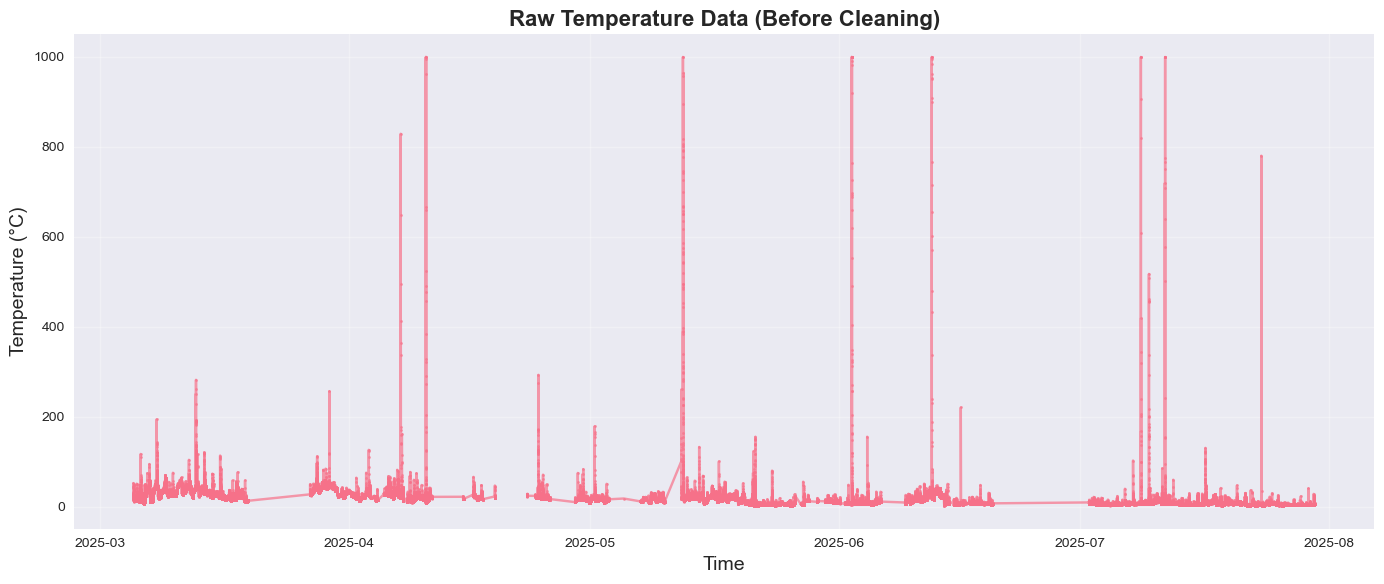

Temperature outliers (>100): 397
Temperature error codes (999.9): 0


In [11]:
# Plot 1: Raw Temperature Data
df_raw = pd.read_csv('feeds.csv', parse_dates=['created_at'])
plt.figure(figsize=(14, 6))
plt.plot(df_raw['created_at'], df_raw['field3'], marker='o', markersize=2, linestyle='-', alpha=0.7)
plt.title('Raw Temperature Data (Before Cleaning)', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print outlier stats
print(f"Temperature outliers (>100): {len(df_raw[df_raw['field3'] > 100])}")
print(f"Temperature error codes (999.9): {len(df_raw[df_raw['field3'] == 999.9])}")

### Plot 2: Outlier Detection (Humidity)
Raw Humidity Data (Before Cleaning) — Visual proof of sensor error codes (e.g., '1999.9') justifying their removal.

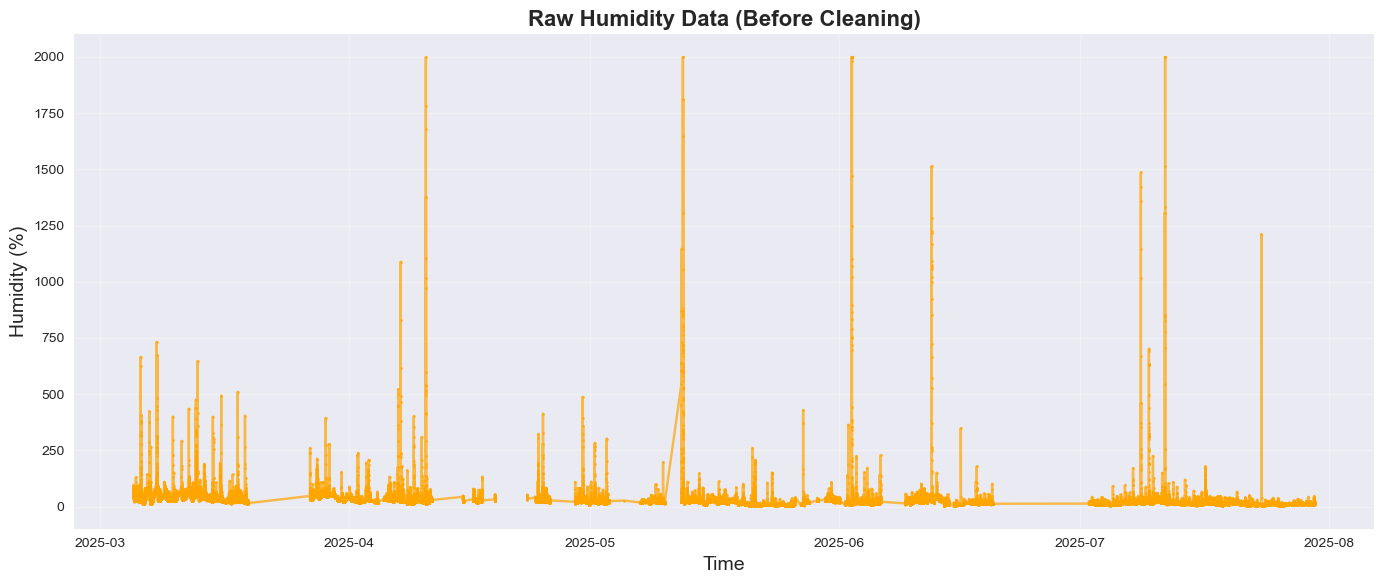

Humidity outliers (>100): 1056
Humidity error codes (1999.9): 0


In [12]:
# Plot 2: Raw Humidity Data
plt.figure(figsize=(14, 6))
plt.plot(df_raw['created_at'], df_raw['field4'], marker='o', markersize=2, linestyle='-', alpha=0.7, color='orange')
plt.title('Raw Humidity Data (Before Cleaning)', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Humidity (%)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print outlier stats
print(f"Humidity outliers (>100): {len(df_raw[df_raw['field4'] > 100])}")
print(f"Humidity error codes (1999.9): {len(df_raw[df_raw['field4'] == 1999.9])}")

### Plot 3: Resampling Justification (Frequency Analysis)
Distribution of Time Gaps in Raw Data — Histogram proving inconsistent frequency, justifying resample('H').mean().

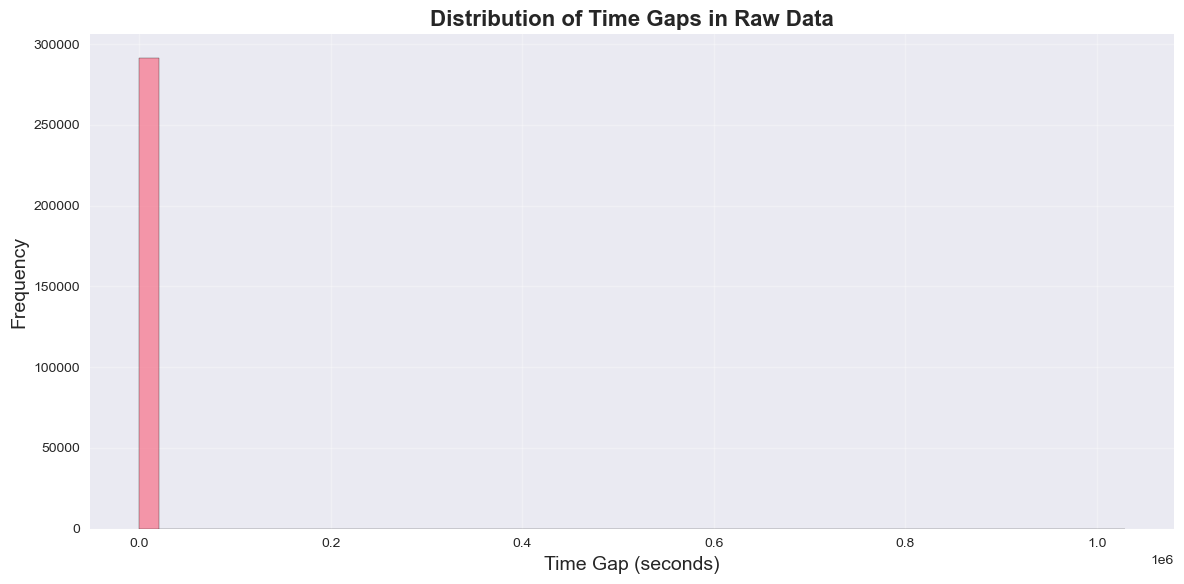

Mean gap: 43.59 seconds
Median gap: 20.00 seconds
Max gap: 1029074.00 seconds
Gaps > 1 hour: 48 instances


In [13]:
# Plot 3: Time Gap Histogram
df_raw_sorted = df_raw.sort_values('created_at')
time_gaps = df_raw_sorted['created_at'].diff().dt.total_seconds()

plt.figure(figsize=(12, 6))
plt.hist(time_gaps.dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Time Gaps in Raw Data', fontsize=16, fontweight='bold')
plt.xlabel('Time Gap (seconds)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print gap statistics
print(f"Mean gap: {time_gaps.mean():.2f} seconds")
print(f"Median gap: {time_gaps.median():.2f} seconds")
print(f"Max gap: {time_gaps.max():.2f} seconds")
print(f"Gaps > 1 hour: {len(time_gaps[time_gaps > 3600])} instances")

### Plot 4: Imputation Method Justification
Comparison of Imputation Methods for Missing Data — Demonstrating time-interpolation vs. global mean fill.

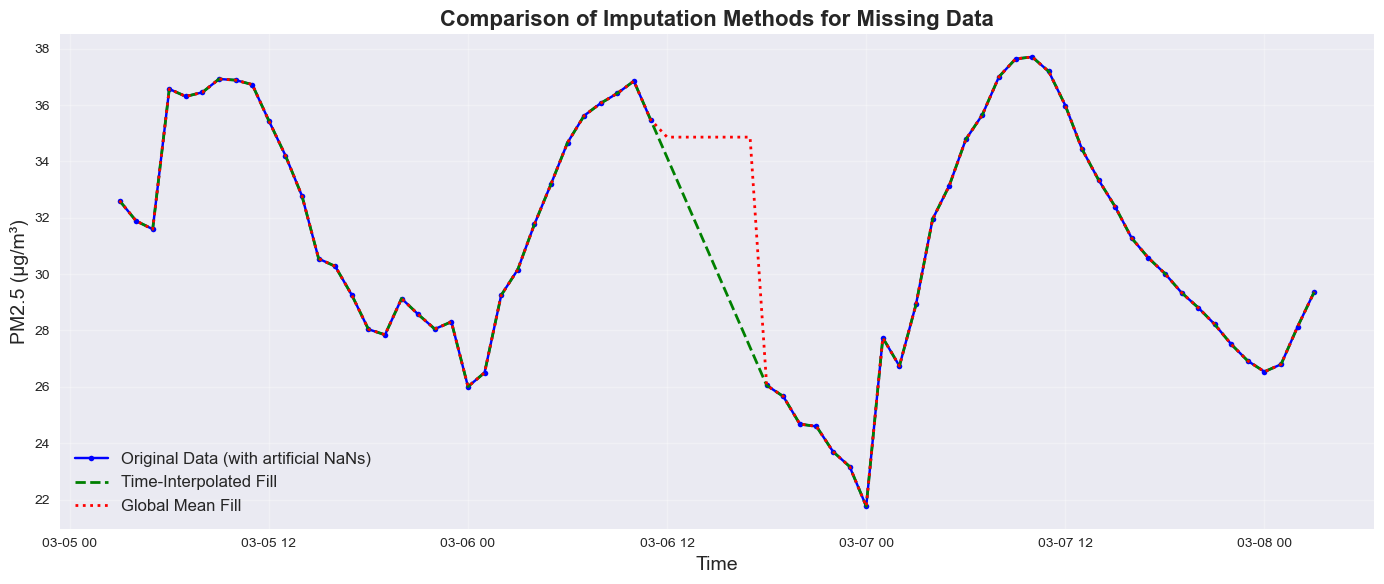

Global mean used for fill: 34.86
Time interpolation range: 27.40 to 34.14


In [14]:
# Plot 4: Imputation Comparison
df_clean = pd.read_csv('feeds_cleaned.csv', parse_dates=['created_at'], index_col='created_at')

# Select a 3-day window
start_date = df_clean.index.min()
end_date = start_date + pd.Timedelta(days=3)
window_data = df_clean.loc[start_date:end_date, 'pm2_5'].copy()

# Artificially create missing data in the middle
missing_start = len(window_data) // 2 - 3
missing_end = len(window_data) // 2 + 3
original_values = window_data.iloc[missing_start:missing_end].copy()
window_data.iloc[missing_start:missing_end] = np.nan

# Time interpolation
time_interp = window_data.interpolate(method='time')

# Global mean fill
global_mean = df_clean['pm2_5'].mean()
mean_fill = window_data.fillna(global_mean)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(window_data.index, window_data, 'o-', label='Original Data (with artificial NaNs)', color='blue', markersize=4)
plt.plot(time_interp.index, time_interp, '--', label='Time-Interpolated Fill', color='green', linewidth=2)
plt.plot(mean_fill.index, mean_fill, ':', label='Global Mean Fill', color='red', linewidth=2)
plt.title('Comparison of Imputation Methods for Missing Data', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 (μg/m³)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Global mean used for fill: {global_mean:.2f}")
print(f"Time interpolation range: {time_interp.iloc[missing_start:missing_end].min():.2f} to {time_interp.iloc[missing_start:missing_end].max():.2f}")

## Part 2: Justifying Phase 3 (EDA)
Exploratory Data Analysis plots.

### Plot 5: Seasonal Decomposition
Seasonal Decomposition of PM2.5 (24-Hour Cycle) — Isolating Trend, Seasonal cycle, and Residuals.

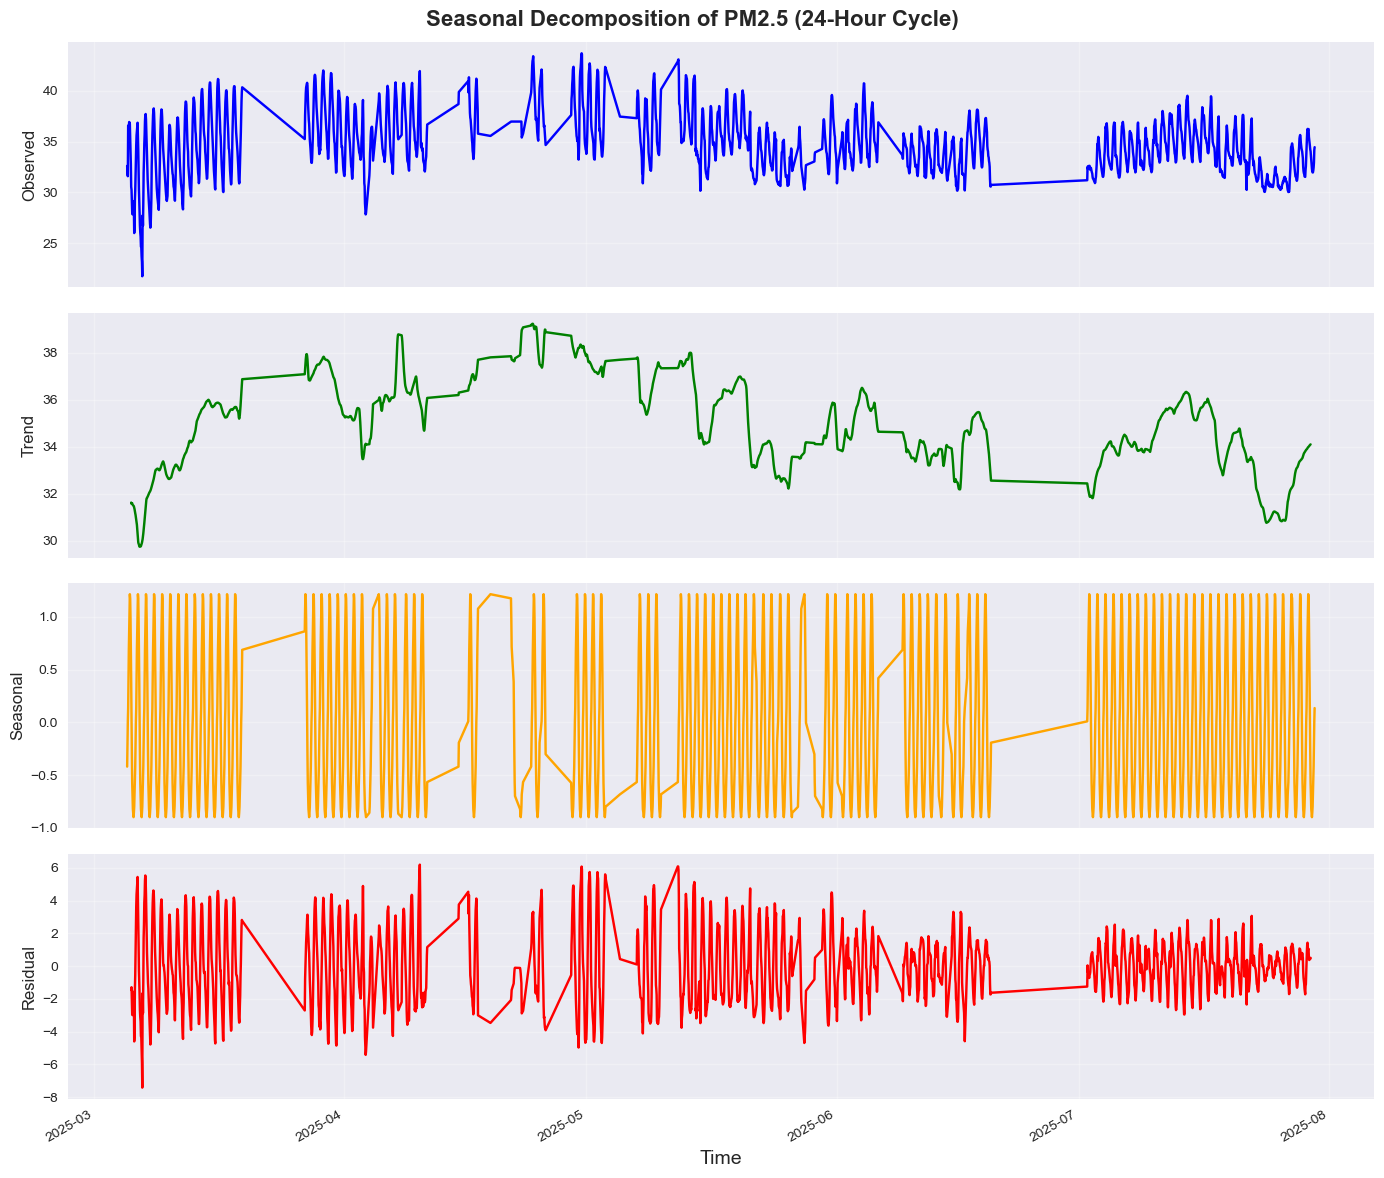

Seasonal component range: -0.90 to 1.22
Strong daily pattern confirmed with period=24


In [15]:
# Plot 5: Seasonal Decomposition
# Ensure no NaNs for seasonal decomposition
pm25_clean = df_clean['pm2_5'].dropna()
decomposition = seasonal_decompose(pm25_clean, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Seasonal Decomposition of PM2.5 (24-Hour Cycle)', fontsize=16, fontweight='bold')

decomposition.observed.plot(ax=axes[0], color='blue')
axes[0].set_ylabel('Observed', fontsize=12)
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color='green')
axes[1].set_ylabel('Trend', fontsize=12)
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color='orange')
axes[2].set_ylabel('Seasonal', fontsize=12)
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_ylabel('Residual', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.xlabel('Time', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Seasonal component range: {decomposition.seasonal.min():.2f} to {decomposition.seasonal.max():.2f}")
print(f"Strong daily pattern confirmed with period=24")

## Part 3: Justifying Phase 4 (Feature Engineering)
Plots demonstrating the value of engineered features.

### Plot 6: Autocorrelation (Lag Feature Justification)
Autocorrelation: PM2.5 at Hour (t-1) vs. Target PM2.5 at Hour (t) — Strong correlation justifies lag features.

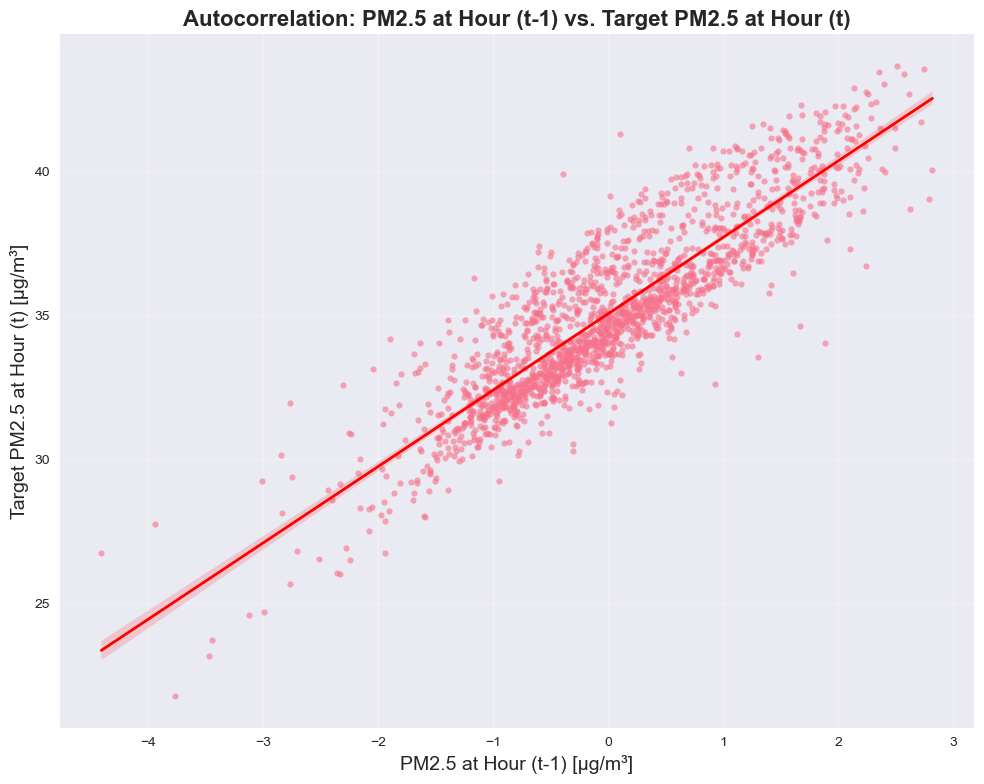

Pearson correlation coefficient: 0.878
Strong positive correlation justifies using lag features.


In [16]:
# Plot 6: Lag Feature Correlation
X_train = np.load('X_train.npy')
y_train = pd.read_csv('y_train.csv', index_col=0)
feature_names = joblib.load('feature_names.pkl')

# Create DataFrame for plotting
df_train = pd.DataFrame(X_train, columns=feature_names)
df_train['target_pm2_5'] = y_train.values

plt.figure(figsize=(10, 8))
sns.regplot(data=df_train, x='pm2_5_lag_1h', y='target_pm2_5', 
            scatter_kws={'alpha':0.6, 's':20}, line_kws={'color':'red', 'linewidth':2})
plt.title('Autocorrelation: PM2.5 at Hour (t-1) vs. Target PM2.5 at Hour (t)', fontsize=16, fontweight='bold')
plt.xlabel('PM2.5 at Hour (t-1) [μg/m³]', fontsize=14)
plt.ylabel('Target PM2.5 at Hour (t) [μg/m³]', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
corr = df_train['pm2_5_lag_1h'].corr(df_train['target_pm2_5'])
print(f"Pearson correlation coefficient: {corr:.3f}")
print("Strong positive correlation justifies using lag features.")

### Plot 7: Daily Pattern (Time Feature Justification)
Distribution of PM2.5 Levels by Hour of the Day — Confirms daily cycle, justifying hour_of_day feature.

C:\Users\burak\AppData\Local\Temp\ipykernel_17896\472296487.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='hour_of_day', y='target_pm2_5', palette='viridis')


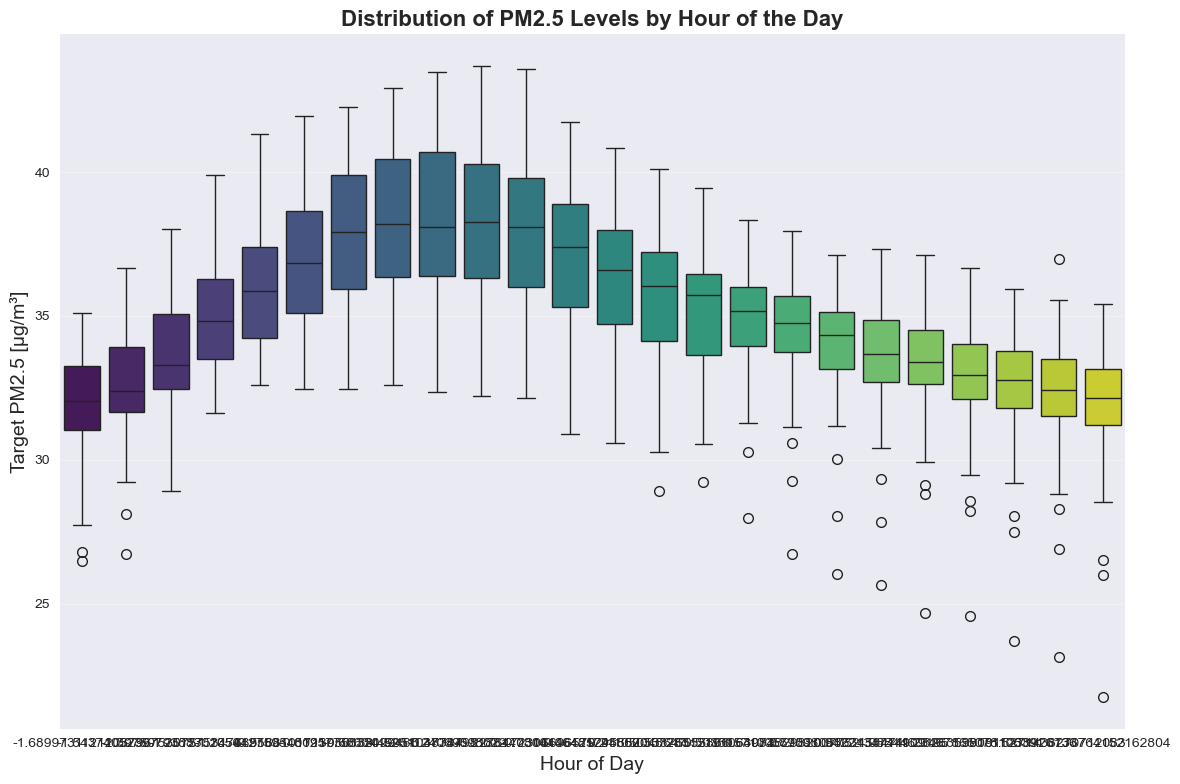

Hourly PM2.5 statistics:
                  mean       std        min        max
hour_of_day                                           
-1.689973    31.956905  1.823073  26.502952  35.089235
-1.543741    32.585369  1.778821  26.738381  36.672998
-1.397508    33.543473  1.878908  28.924934  38.007113
-1.251275    34.974819  1.896714  31.626602  39.908131
-1.105043    35.904145  2.068218  32.603689  41.315280
-0.958810    36.901735  2.191604  32.470862  41.939483
-0.812578    37.794123  2.357483  32.449216  42.272809
-0.666345    38.290098  2.481983  32.618323  42.920073
-0.520112    38.410978  2.609189  32.364929  43.457121
-0.373880    38.255886  2.646767  32.229335  43.680306
-0.227647    37.929245  2.541907  32.161689  43.578326
-0.081415    37.137628  2.314783  30.902820  41.743845
 0.064818    36.325637  2.192905  30.601689  40.819513
 0.211051    35.609025  2.134171  28.935008  40.101108
 0.357283    35.183937  2.031873  29.239953  39.432378
 0.503516    34.854964  1.926629  27.981

In [17]:
# Plot 7: Daily Pattern Boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_train, x='hour_of_day', y='target_pm2_5', palette='viridis')
plt.title('Distribution of PM2.5 Levels by Hour of the Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Target PM2.5 [μg/m³]', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Calculate hourly statistics
hourly_stats = df_train.groupby('hour_of_day')['target_pm2_5'].agg(['mean', 'std', 'min', 'max'])
print("Hourly PM2.5 statistics:")
print(hourly_stats)
print("\nClear daily pattern justifies hour_of_day as a feature.")